In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, special

## Zadanie 1 – Predkosc strzaly z luku

Energia kinetyczna = praca naciagniecia luku:
$$\frac{1}{2}mv^2 = \int_0^L F\,dx$$

  Praca W = 74.5333 J
  Predkosc strzaly v = 44.5820 m/s


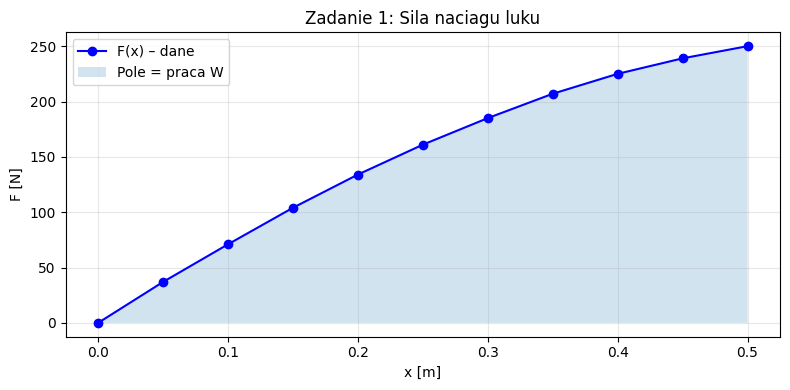

In [2]:
x_data = np.array([0.00, 0.05, 0.10, 0.15, 0.20,
                   0.25, 0.30, 0.35, 0.40, 0.45, 0.50], dtype=np.float64)
F_data = np.array([0, 37, 71, 104, 134,
                   161, 185, 207, 225, 239, 250], dtype=np.float64)

L = np.float64(0.50)
m = np.float64(0.075)


W_simpson = np.float64(integrate.simpson(F_data, x=x_data))


v_simpson = np.sqrt(np.float64(2.0) * W_simpson / m)


print(f"  Praca W = {W_simpson:.4f} J")
print(f"  Predkosc strzaly v = {v_simpson:.4f} m/s")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_data, F_data, 'b-o', markersize=6, label='F(x) – dane')
ax.fill_between(x_data, F_data, alpha=0.2, label='Pole = praca W')
ax.set_xlabel('x [m]')
ax.set_ylabel('F [N]')
ax.set_title('Zadanie 1: Sila naciagu luku')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Zadanie 2 – Cialo na sprezynie z tarciem

### (a) Predkosc v0 w punkcie x = 0

Calka = 3.119190
Blad szacowany = 3.46e-14
Predkosc v0 = 2.497675 m/s


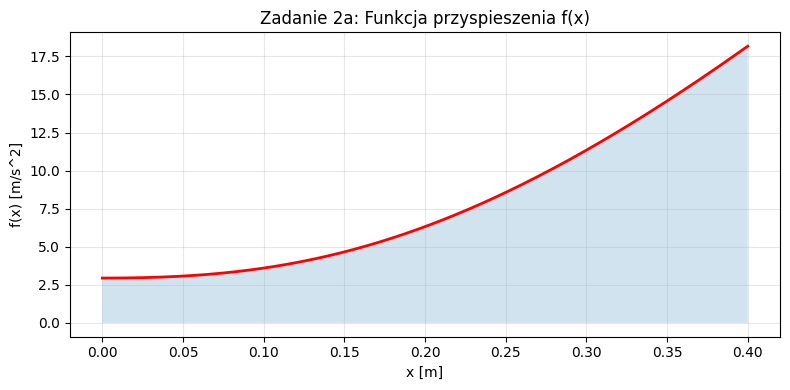

In [3]:
m2  = np.float64(0.8)
l2  = np.float64(0.4)
mu  = np.float64(0.3)
k   = np.float64(80.0)
g   = np.float64(9.81)

def f2(x):
    x = np.float64(x)
    return mu * g + (k / m2) * (mu * l2 + x) * (np.float64(1.0) - l2 / np.sqrt(l2**2 + x**2))

W2, err2 = integrate.quad(f2, 0.0, float(l2))
W2 = np.float64(W2)
v0 = np.sqrt(np.float64(2.0) * W2)

print(f"Calka = {W2:.6f}")
print(f"Blad szacowany = {err2:.2e}")
print(f"Predkosc v0 = {v0:.6f} m/s")

x_plot = np.linspace(0, float(l2), 300, dtype=np.float64)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_plot, f2(x_plot), 'r-', linewidth=2)
ax.fill_between(x_plot, f2(x_plot), alpha=0.2)
ax.set_xlabel('x [m]')
ax.set_ylabel('f(x) [m/s^2]')
ax.set_title('Zadanie 2a: Funkcja przyspieszenia f(x)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### (b) Stala C i czas t

$$C = \int_0^1 \left[(\sqrt{2}-1)^2 - (\sqrt{1+z}-1)^2\right]^{-1/2} dz$$

Osobliwosc w z=1 zachowuje sie jak $(1-z)^{-1/2}$ 

In [4]:
def integrand_C(z):
    z = np.float64(z)
    A = (np.sqrt(np.float64(2.0)) - np.float64(1.0))**2
    B = (np.sqrt(np.float64(1.0) + z) - np.float64(1.0))**2
    val = A - B
    val = np.where(val <= np.float64(0.0), np.float64(1e-30), val)
    return np.float64(1.0) / np.sqrt(val)

C_val, err_C = integrate.quad(
    integrand_C, 0.0, 1.0,
    limit=200,
    points=[0.99],
    epsabs=1e-10, epsrel=1e-10
)
C_val = np.float64(C_val)

t_val = C_val * np.sqrt(m2 / k)

print(f"Stala C = {C_val:.6f}")
print(f"Blad szacowany quad = {err_C:.2e}")
print(f"Czas t = C * sqrt(m/k) = {C_val:.6f} * {np.sqrt(m2/k):.6f} = {t_val:.6f} s")

Stala C = 3.970020
Blad szacowany quad = 1.24e-10
Czas t = C * sqrt(m/k) = 3.970020 * 0.100000 = 0.397002 s


## Zadanie 3 – Wahadlo matematyczne

### (a) Calka eliptyczna kwadraturam

In [5]:
theta0_deg = np.float64(45.0)
theta0     = np.deg2rad(theta0_deg)
l3         = np.float64(1.0)
g3         = np.float64(9.81)

k_mod = np.sin(theta0 / np.float64(2.0))

K_true = np.float64(special.ellipk(k_mod**2))
print(f"k = sin(theta0/2) = {k_mod:.8f}")
print(f"K(k) z scipy.special.ellipk = {K_true:.8f}")

def elliptic_integrand(theta, k):
    return np.float64(1.0) / np.sqrt(np.float64(1.0) - k**2 * np.sin(np.float64(theta))**2)

K_quad, err_K = integrate.quad(elliptic_integrand, 0.0, np.pi/2, args=(float(k_mod),))
K_quad = np.float64(K_quad)

T0 = np.float64(2.0) * np.pi * np.sqrt(l3 / g3)
T_true_quad = np.float64(4.0) * np.sqrt(l3 / g3) * K_quad

print(f"K(k) kwadratura = {K_quad:.8f}")
print(f"Blad wzgledny K (kwadratura vs scipy) = {abs(K_quad - K_true)/K_true:.2e}")
print(f"Okres T(theta0=45deg) = {T_true_quad:.6f} s")
print(f"Przyblizony okres T0  = {T0:.6f} s")

k = sin(theta0/2) = 0.38268343
K(k) z scipy.special.ellipk = 1.63358631
K(k) kwadratura = 1.63358631
Blad wzgledny K (kwadratura vs scipy) = 1.36e-16
Okres T(theta0=45deg) = 2.086256 s
Przyblizony okres T0  = 2.006067 s


### (b) Calka eliptyczna przez AGM

K(k) AGM (20 iter) = 1.63358631
Blad wzgledny AGM = 0.00e+00
Okres T(theta0=45deg) AGM = 2.086256 s


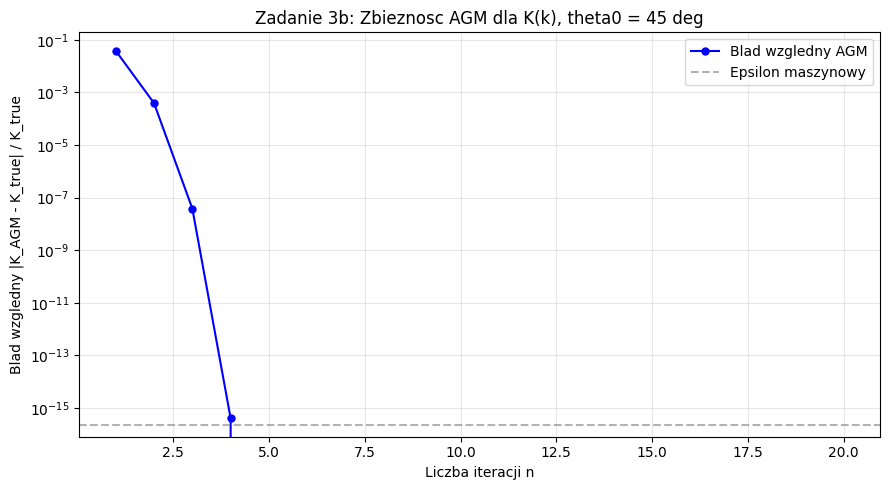

In [6]:
def agm_K(k_val, n_iter):
    a = np.float64(1.0) + np.float64(k_val)
    b = np.float64(1.0) - np.float64(k_val)
    for _ in range(n_iter):
        a_new = (a + b) / np.float64(2.0)
        b_new = np.sqrt(a * b)
        a, b = a_new, b_new
    return (np.pi / np.float64(2.0)) / a

max_iter = 20
iterations = np.arange(1, max_iter + 1)
K_agm_vals = np.array([agm_K(k_mod, n) for n in iterations], dtype=np.float64)
rel_errors_agm = np.abs(K_agm_vals - K_true) / K_true

K_agm_final = K_agm_vals[-1]
T_agm = np.float64(4.0) * np.sqrt(l3 / g3) * K_agm_final

print(f"K(k) AGM ({max_iter} iter) = {K_agm_final:.8f}")
print(f"Blad wzgledny AGM = {rel_errors_agm[-1]:.2e}")
print(f"Okres T(theta0=45deg) AGM = {T_agm:.6f} s")

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(iterations, rel_errors_agm, 'b-o', markersize=5, label='Blad wzgledny AGM')
ax.axhline(np.finfo(np.float64).eps, color='gray', linestyle='--', alpha=0.6, label='Epsilon maszynowy')
ax.set_xlabel('Liczba iteracji n')
ax.set_ylabel('Blad wzgledny |K_AGM - K_true| / K_true')
ax.set_title('Zadanie 3b: Zbieznosc AGM dla K(k), theta0 = 45 deg')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

### Blad wzgledny okresu T0 (przyblizenie malych drgan) vs theta0

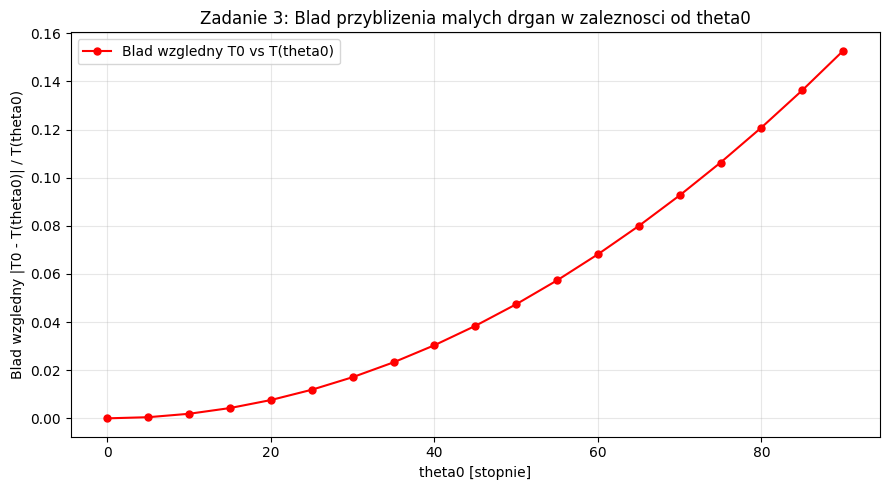

theta0 = 45 deg: blad wzgledny T0 = 0.0384 (3.84%)
theta0 = 90 deg: blad wzgledny T0 = 0.1528 (15.28%)


In [7]:
theta0_deg_arr = np.arange(0, 91, 5, dtype=np.float64)
theta0_arr     = np.deg2rad(theta0_deg_arr)

T0_approx = np.float64(2.0) * np.pi * np.sqrt(l3 / g3)

T_exact = np.zeros_like(theta0_arr)
for i, th in enumerate(theta0_arr):
    k_i = np.sin(np.float64(th) / np.float64(2.0))
    K_i = np.float64(special.ellipk(float(k_i**2)))
    T_exact[i] = np.float64(4.0) * np.sqrt(l3 / g3) * K_i

T_exact[0] = T0_approx

rel_err_T = np.abs(T0_approx - T_exact) / T_exact

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(theta0_deg_arr, np.where(rel_err_T < 1e-17, 1e-17, rel_err_T),
            'r-o', markersize=5, label='Blad wzgledny T0 vs T(theta0)')
ax.set_xlabel('theta0 [stopnie]')
ax.set_ylabel('Blad wzgledny |T0 - T(theta0)| / T(theta0)')
ax.set_title('Zadanie 3: Blad przyblizenia malych drgan w zaleznosci od theta0')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"theta0 = 45 deg: blad wzgledny T0 = {rel_err_T[9]:.4f} ({rel_err_T[9]*100:.2f}%)")
print(f"theta0 = 90 deg: blad wzgledny T0 = {rel_err_T[18]:.4f} ({rel_err_T[18]*100:.2f}%)")